# Outcome validation: does coupling coherence predict placement?

The completer / analysis pages frame **Score** (= -H, higher is better) as a quality
signal, but the model is only ever fit to team *co-occurrence* -- it has never seen a
single tournament result. This notebook asks the missing question directly: **do teams
the model rates as more coherent actually place better?**

**Hypothesis.** A strong team won't save a weak player, so **high-coherence teams should
spread across the whole result range**, while **low-coherence teams should cluster near
the bottom**. That is a claim about the *conditional distribution* of placement given
coherence (heteroscedastic: the best finishes are reachable mainly from high coherence,
but high coherence guarantees nothing), not merely a mean trend -- a single correlation
coefficient can wash it out, so we look at conditional quantiles and spread per coherence
bin, not just Spearman rho.

**Why an in-sample fit is fine here (no leakage).** Elsewhere we use chronological
out-of-time splits because the model predicts *membership*, which is exactly what it is
fit on. Placement is different: `(J, h)` carry zero information about who won, so scoring
a team's coherence and relating it to that team's finish is not circular even when the
team is in the fit corpus. We therefore fit on the full corpus for maximum power, and
add an out-of-time refit at the end as a robustness check.

**Outcome encoding.** `placement_pct = 1 - (placing - 1)/(field - 1)` in [0, 1], where
**1.0 = event winner and 0.0 = last**, normalized within each tournament so events of
different size are comparable. `field` is the largest placing observed in the event (so
it counts placed players whose roster we couldn't parse). Win rate (`wins / games`) is a
finer-grained secondary outcome with fewer bottom-end ties.

> Requires cache schema >= v2 (placing + record). If this was last ingested under v1,
> re-run `python -m k2dex.tournament_ingest` first.

In [ ]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from k2dex import tournament_ingest
from k2dex.constants import (
    PHASE2_MIN_TEAM_COUNT, SPECIES_LR_C, SPECIES_ITEM_LR_C, TEAM_SIZE,
    VALIDATION_TEAM_FRAC_TEST,
)
from k2dex.models import fit_pl_ising

tournaments = tournament_ingest.load_cached_tournaments()
teams_out = tournament_ingest.all_teams_with_outcomes(tournaments)
n_placed = sum(1 for t in teams_out if t.placing is not None)
n_record = sum(1 for t in teams_out if (t.wins + t.losses + t.ties) > 0)

print(f"tournaments:          {len(tournaments)}")
print(f"team-appearances:     {len(teams_out)}")
print(f"with placing:         {n_placed} ({n_placed / len(teams_out):.1%})")
print(f"with win/loss record: {n_record} ({n_record / len(teams_out):.1%})")
assert n_placed > 0, (
    "No placing data found -- cache predates CACHE_VERSION 2. "
    "Re-run `python -m k2dex.tournament_ingest` to refetch with outcomes."
)

## Fit both models on the full corpus

Same vocab cutoffs and per-model regularization as everywhere else
(`SPECIES_LR_C` / `SPECIES_ITEM_LR_C`). Fit on every team -- see the leakage note above.

In [2]:
all_full = tournament_ingest.all_teams(tournaments)            # (species, item) frozensets
all_species = tournament_ingest.species_only_teams(all_full)   # species-only frozensets

# --- Species model ---
species_counts = Counter(s for team in all_species for s in team)
vocab = sorted(s for s, c in species_counts.items() if c >= PHASE2_MIN_TEAM_COUNT)
name_to_idx = {s: i for i, s in enumerate(vocab)}
V = len(vocab)
X = np.zeros((len(all_species), V), dtype=np.int8)
for ti, team in enumerate(all_species):
    for s in team:
        j = name_to_idx.get(s)
        if j is not None:
            X[ti, j] = 1
J, h = fit_pl_ising(X.astype(np.int32), C=SPECIES_LR_C)

# --- Species @ item model ---
pair_counts = Counter(p for team in all_full for p in team)
pair_vocab = sorted(
    (p for p, c in pair_counts.items() if c >= PHASE2_MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
V_pair = len(pair_vocab)
X_pair = np.zeros((len(all_full), V_pair), dtype=np.int8)
for ti, team in enumerate(all_full):
    for p in team:
        j = pair_to_idx.get(p)
        if j is not None:
            X_pair[ti, j] = 1
J_pair, h_pair = fit_pl_ising(X_pair.astype(np.int32), C=SPECIES_ITEM_LR_C)

print(f"species model:      V={V:>4}   teams={len(all_species)}")
print(f"species@item model: V={V_pair:>4}   teams={len(all_full)}")

species model:      V= 193   teams=18388
species@item model: V= 741   teams=18388


## Score every team and attach its outcome

For each team we compute the three Score components used on the analysis page --
**coherence** (`0.5 s'Js`), **popularity** (`h.s`), and **Score** (their sum, = -H at
`field_weight = 1`) -- and pair them with the team's normalized placement and win rate.
Teams with any out-of-vocab member are dropped for that model (rare-member roster below
the count-5 cutoff).

In [3]:
def scored_table(tournaments, idx_of, V, J, h):
    '''Score every parseable team under one fitted model and attach outcomes.

    idx_of(members) maps a team's (species, item) frozenset to a list of vocab
    indices, or None if any member is out-of-vocabulary (team dropped for this
    model). placement_pct is normalized within each tournament: 1.0 = event
    winner, 0.0 = worst placed; field = largest placing observed in the event.
    '''
    rows, ppct, wrate = [], [], []
    for t in tournaments:
        placed = [tm.placing for tm in t.teams if tm.placing is not None]
        field = max(placed) if placed else None
        for tm in t.teams:
            idxs = idx_of(tm.members)
            if idxs is None:
                continue
            v = np.zeros(V, dtype=bool)
            v[idxs] = True
            rows.append(v)
            if tm.placing is not None and field and field > 1:
                ppct.append(1.0 - (tm.placing - 1) / (field - 1))
            else:
                ppct.append(np.nan)
            g = tm.wins + tm.losses + tm.ties
            wrate.append(tm.wins / g if g > 0 else np.nan)
    s = np.array(rows, dtype=np.float64)
    pop = s @ h
    coh = 0.5 * np.sum(s * (s @ J), axis=1)
    return {
        "coherence": coh, "popularity": pop, "score": pop + coh,
        "placement_pct": np.array(ppct), "winrate": np.array(wrate),
    }


def species_idx(members):
    out = []
    for sp, _item in members:
        j = name_to_idx.get(sp)
        if j is None:
            return None
        out.append(j)
    return out


def pair_idx(members):
    out = []
    for p in members:
        j = pair_to_idx.get(p)
        if j is None:
            return None
        out.append(j)
    return out


tbl_sp = scored_table(tournaments, species_idx, V, J, h)
tbl_pr = scored_table(tournaments, pair_idx, V_pair, J_pair, h_pair)
for name, tbl in [("species", tbl_sp), ("species@item", tbl_pr)]:
    n = len(tbl["coherence"])
    nph = int(np.sum(~np.isnan(tbl["placement_pct"])))
    print(f"{name:<13} scored={n:>6}  with placement={nph:>6}")

species       scored= 18347  with placement= 16356
species@item  scored= 16672  with placement= 14878


## Association: is more coherent = better placed?

Pooled Spearman rho across all scored teams. **Positive rho means higher predictor ->
better finish.** We report all three predictors against both outcomes; if coherence
carries real signal it should beat popularity, and Score (their sum) should sit between
them.

In [4]:
def assoc(tbl, x_key, y_key):
    x, y = tbl[x_key], tbl[y_key]
    m = ~(np.isnan(x) | np.isnan(y))
    rho, p = spearmanr(x[m], y[m])
    return rho, p, int(m.sum())


print(f"{'model':<13} {'predictor':<12} {'outcome':<14} {'spearman':>9} {'p':>10} {'n':>7}")
for name, tbl in [("species", tbl_sp), ("species@item", tbl_pr)]:
    for pred in ["coherence", "popularity", "score"]:
        for outc in ["placement_pct", "winrate"]:
            rho, p, n = assoc(tbl, pred, outc)
            print(f"{name:<13} {pred:<12} {outc:<14} {rho:>+9.4f} {p:>10.2e} {n:>7}")

model         predictor    outcome         spearman          p       n
species       coherence    placement_pct    -0.0365   2.96e-06   16356
species       coherence    winrate          -0.0471   1.73e-10   18347
species       popularity   placement_pct    +0.1090   2.17e-44   16356
species       popularity   winrate          +0.1258   1.21e-65   18347
species       score        placement_pct    +0.1365   7.56e-69   16356
species       score        winrate          +0.1545   2.09e-98   18347
species@item  coherence    placement_pct    -0.0325   7.43e-05   14878
species@item  coherence    winrate          -0.0400   2.32e-07   16672
species@item  popularity   placement_pct    +0.1082   5.65e-40   14878
species@item  popularity   winrate          +0.1191   9.59e-54   16672
species@item  score        placement_pct    +0.1289   4.16e-56   14878
species@item  score        winrate          +0.1397   1.99e-73   16672


### Controlling for the event: within-tournament rank correlation

A pooled correlation can be confounded by event difficulty and meta drift (a strong
global team may be off-meta at one event). Computing Spearman **inside each tournament**
and looking at the distribution of those rhos removes the between-event variance and is
the cleaner test of "within the same field, do more coherent teams place higher?".

In [5]:
def per_tournament_spearman(tournaments, idx_of, J, h, pred="coherence", min_field=8):
    rhos = []
    for t in tournaments:
        placed = [tm.placing for tm in t.teams if tm.placing is not None]
        field = max(placed) if placed else None
        if not field or field < min_field:
            continue
        xs, ys = [], []
        for tm in t.teams:
            idxs = idx_of(tm.members)
            if idxs is None or tm.placing is None:
                continue
            v = np.zeros_like(h, dtype=np.float64)
            v[idxs] = 1.0
            coh = 0.5 * float(v @ (J @ v))
            pop = float(h @ v)
            val = {"coherence": coh, "popularity": pop, "score": coh + pop}[pred]
            xs.append(val)
            ys.append(1.0 - (tm.placing - 1) / (field - 1))
        if len(xs) >= min_field:
            rho, _ = spearmanr(xs, ys)
            if not np.isnan(rho):
                rhos.append(rho)
    return np.array(rhos)


for pred in ["coherence", "popularity", "score"]:
    r = per_tournament_spearman(tournaments, pair_idx, J_pair, h_pair, pred)
    print(f"species@item  within-event spearman({pred:<10}, placement):  "
          f"events={len(r):>3}  mean={r.mean():+.3f}  median={np.median(r):+.3f}  "
          f"frac>0={np.mean(r > 0):.0%}")

species@item  within-event spearman(coherence , placement):  events=158  mean=-0.050  median=-0.051  frac>0=37%
species@item  within-event spearman(popularity, placement):  events=158  mean=+0.122  median=+0.114  frac>0=84%
species@item  within-event spearman(score     , placement):  events=158  mean=+0.136  median=+0.124  frac>0=82%


## The hypothesis: conditional distribution of placement by coherence

The mean trend above is not the hypothesis. The hypothesis is about *spread*: bin teams
into coherence quintiles and look at the full placement distribution per bin. We expect:

- **p90 (best case)** to rise with coherence -- top finishes concentrate among coherent teams.
- **p10 (worst case)** to stay low across all bins -- coherence never guarantees a result.
- **spread (p90 - p10)** to widen with coherence -- high-coherence teams fan out, low-coherence teams pile up at the bottom.

If instead every quintile has the same spread and only the median shifts, the relationship
is a plain mean effect, not the heteroscedastic story.

coherence quintile          n   mean    p10    p50    p90  spread  P(top25%)  P(>=0.95)
Q1 [-25.03,-4.39)        2976  0.520   0.11   0.53   0.91    0.80      28.2%       6.2%
Q2 [-4.39,-1.52)         2975  0.527   0.11   0.54   0.92    0.81      28.5%       6.7%
Q3 [-1.52,+1.30)         2976  0.510   0.11   0.52   0.90    0.79      26.0%       5.3%
Q4 [+1.30,+4.82)         2975  0.508   0.10   0.52   0.91    0.81      26.1%       5.7%
Q5 [+4.82,+18.09)        2976  0.496   0.08   0.49   0.90    0.82      25.3%       5.6%


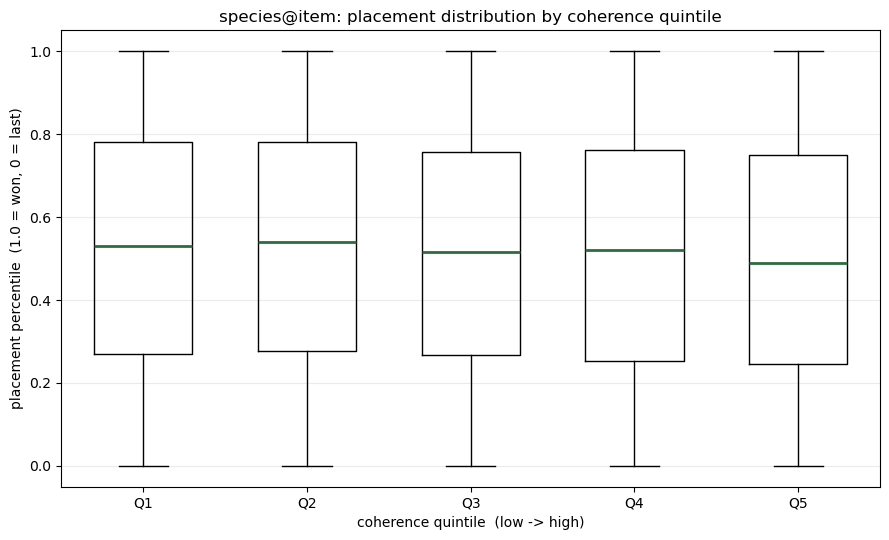

In [6]:
def coherence_bins(tbl, predictor="coherence", outcome="placement_pct", n_bins=5):
    x, y = tbl[predictor], tbl[outcome]
    m = ~(np.isnan(x) | np.isnan(y))
    x, y = x[m], y[m]
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    b = np.clip(np.digitize(x, edges[1:-1]), 0, n_bins - 1)
    return x, y, b, edges


x, y, b, edges = coherence_bins(tbl_pr, "coherence", "placement_pct", 5)

hdr = (f"{'coherence quintile':<22} {'n':>6} {'mean':>6} {'p10':>6} {'p50':>6} "
       f"{'p90':>6} {'spread':>7} {'P(top25%)':>10} {'P(>=0.95)':>10}")
print(hdr)
groups = []
for k in range(5):
    yk = y[b == k]
    groups.append(yk)
    q10, q50, q90 = np.quantile(yk, [0.1, 0.5, 0.9])
    label = f"Q{k + 1} [{edges[k]:+.2f},{edges[k + 1]:+.2f})"
    print(f"{label:<22} {len(yk):>6} {yk.mean():>6.3f} {q10:>6.2f} {q50:>6.2f} "
          f"{q90:>6.2f} {q90 - q10:>7.2f} {np.mean(yk >= 0.75):>10.1%} "
          f"{np.mean(yk >= 0.95):>10.1%}")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(groups, showfliers=False, widths=0.6,
           medianprops=dict(color="#2e6b3f", linewidth=2))
ax.set_xticklabels([f"Q{k + 1}" for k in range(5)])
ax.set_xlabel("coherence quintile  (low -> high)")
ax.set_ylabel("placement percentile  (1.0 = won, 0 = last)")
ax.set_title("species@item: placement distribution by coherence quintile")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

## Coherence vs popularity vs Score: which carries the signal?

Repeat the conditional-quantile view for each predictor. Coherence is the interesting
one; popularity (`h.s`) is the "is this a netdecked meta team" axis and is the obvious
confound -- popular teams are piloted by a mix of strong and weak players. If the
spread-widening shape is present for coherence but flat for popularity, that's evidence
the pairwise structure -- not just bandwagon popularity -- tracks competitive viability.

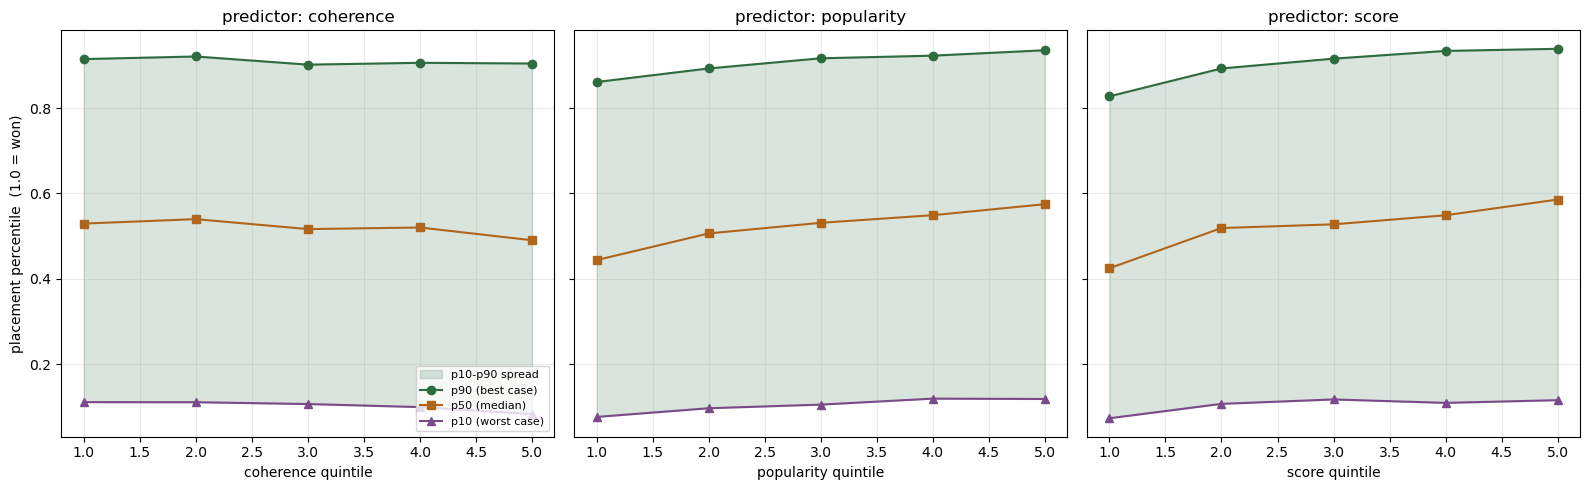

In [7]:
preds = ["coherence", "popularity", "score"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, pred in zip(axes, preds):
    x, y, b, edges = coherence_bins(tbl_pr, pred, "placement_pct", 5)
    xs = range(1, 6)
    p10 = [np.quantile(y[b == k], 0.10) for k in range(5)]
    p50 = [np.quantile(y[b == k], 0.50) for k in range(5)]
    p90 = [np.quantile(y[b == k], 0.90) for k in range(5)]
    ax.fill_between(xs, p10, p90, alpha=0.18, color="#2e6b3f", label="p10-p90 spread")
    ax.plot(xs, p90, "o-", color="#2e6b3f", label="p90 (best case)")
    ax.plot(xs, p50, "s-", color="#b0651a", label="p50 (median)")
    ax.plot(xs, p10, "^-", color="#7a4a8a", label="p10 (worst case)")
    ax.set_title(f"predictor: {pred}")
    ax.set_xlabel(f"{pred} quintile")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("placement percentile  (1.0 = won)")
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## Robustness: out-of-time refit

The leakage argument above says an in-sample fit is legitimate, but this confirms it: refit
the species@item model on the chronological train split only, then score the held-out
*future* test teams. If the association survives on teams the model was never fit on, the
relationship isn't an artifact of scoring teams with a model that saw them.

In [8]:
tr, te = tournament_ingest.chronological_split(tournaments, 1.0 - VALIDATION_TEAM_FRAC_TEST)
tr_full = tournament_ingest.all_teams(tr)
pc = Counter(p for team in tr_full for p in team)
pv = sorted((p for p, c in pc.items() if c >= PHASE2_MIN_TEAM_COUNT),
            key=lambda p: (p[0], p[1] or ""))
p2i = {p: i for i, p in enumerate(pv)}
Vp = len(pv)
Xtr = np.zeros((len(tr_full), Vp), dtype=np.int8)
for ti, team in enumerate(tr_full):
    for p in team:
        j = p2i.get(p)
        if j is not None:
            Xtr[ti, j] = 1
Jt, ht = fit_pl_ising(Xtr.astype(np.int32), C=SPECIES_ITEM_LR_C)


def pair_idx_oot(members):
    out = []
    for p in members:
        j = p2i.get(p)
        if j is None:
            return None
        out.append(j)
    return out


tbl_oot = scored_table(te, pair_idx_oot, Vp, Jt, ht)
print(f"out-of-time test teams scored: {len(tbl_oot['coherence'])}  "
      f"(train events={len(tr)}, test events={len(te)})")
for pred in ["coherence", "popularity", "score"]:
    rho, p, n = assoc(tbl_oot, pred, "placement_pct")
    print(f"OOT species@item  {pred:<11} vs placement:  rho={rho:>+.4f}  p={p:.2e}  n={n}")

out-of-time test teams scored: 1705  (train events=126, test events=32)
OOT species@item  coherence   vs placement:  rho=+0.0183  p=4.85e-01  n=1459
OOT species@item  popularity  vs placement:  rho=+0.0446  p=8.87e-02  n=1459
OOT species@item  score       vs placement:  rho=+0.0662  p=1.14e-02  n=1459


## Interpretation

**Headline: coherence does not predict placement, and the hypothesis (heteroscedastic
spread) is not supported.** This is a confirmatory result, not a surprising one -- the
model is a generative model of the *meta* (what teams look like), never a placement
predictor, so the check bounds what the descriptive model claims rather than revealing a
flaw.

What the run shows:

- **Coherence is null-to-slightly-negative for placement.** Pooled Spearman ~ -0.03 to
  -0.05; within-event mean -0.05, median -0.051, positive in only 37% of events. The
  coherence-quintile table is the decisive evidence: the placement distribution is
  essentially **flat across all five bins** -- mean ~0.50, p10 ~0.10, p90 ~0.90, spread
  ~0.80 in every quintile. There is no mean shift and no spread-widening, so neither a
  plain mean effect nor the hypothesized heteroscedastic shape is present.
- **Popularity (`h·s`) is the only composition signal that tracks placement**, and it is
  robust within-event (mean +0.12, positive in 84% of events). Score correlates with
  placement (+0.13) *only* through its popularity term; coherence contributes nothing and
  drags slightly. Mechanistically this is just "teams built from current meta-staple
  Pokémon place a bit better" -- meta-conformity, not combinatorial coherence.
- **The magnitude is small either way.** Even popularity is rho ~0.11 (~1% of placement
  variance). Placement is dominated by player skill, matchups, and variance -- a fact
  about VGC, not about the fit. Team composition simply explains very little of who wins.
- **Out-of-time, the effects attenuate** (coherence +0.018 n.s., popularity +0.045
  marginal, Score +0.066 p=0.01), consistent with the meta-conformity signal being partly
  transient (cf. `temporal_drift.ipynb`).

**Takeaway.** Score measures *typicality / meta-conformity*, not *team quality*. That is
exactly what a meta-generative model should do, and it is consistent with
`energy_discrimination.ipynb` (coherence separates real teams from a usage null -- a
**plausibility** axis, distinct from a **placement** axis). Describe the model as
capturing meta structure, and avoid implying Score is a win-probability ordering.

**Scope note.** This tests only whether the *meta-generative* fit incidentally encodes
placement; it does not test whether placement *could* be modeled. Folding placement into
the fit (e.g. a success-weighted PL fit) would be a fundamentally different object -- a
placement-predictive model rather than a descriptive meta model -- and is deliberately
left out of scope here; it warrants its own deliberation before any such change.
